In [40]:
import pandas as pd
import numpy as np
import time
import psutil
import threading
import os
import folium
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Classe para monitoramento de hardware

In [41]:
class MonitorHardware:
    def __init__(self, label="Tarefa", intervalo=0.1):
        self.label = label
        self.intervalo = intervalo
        self.monitorando = False
        self.dados = {
            "cpu_avg": 0, "cpu_max": 0,
            "ram_avg": 0, "ram_max": 0
        }
        self._thread = None
        self.num_cores = psutil.cpu_count(logical=True)

    def __enter__(self):
        self.monitorando = True
        self._thread = threading.Thread(target=self._coletar_metricas)
        self._thread.start()
        return self

    def __exit__(self, exc_type, exc_val, exc_tb):
        self.monitorando = False
        if self._thread:
            self._thread.join()
        
        # Resumo ao sair do bloco
        print(f"[{self.label}] CPU Méd: {self.dados['cpu_avg']:.1f}% (Max: {self.dados['cpu_max']:.1f}%) | "
              f"RAM Méd: {self.dados['ram_avg']:.1f}MB (Max: {self.dados['ram_max']:.1f}MB)")

    def _coletar_metricas(self):
        processo_pai = psutil.Process(os.getpid())
        cpus = []
        rams = []
        
        # Primeira leitura de CPU é descarte
        processo_pai.cpu_percent(interval=None)
        
        while self.monitorando:
            try:
                # Pega processo atual e filhos (importante para n_jobs=-1 do sklearn)
                filhos = processo_pai.children(recursive=True)
                processos = [processo_pai] + filhos
                
                # Soma CPU e RAM de todos os processos
                cpu_total = sum(p.cpu_percent(interval=None) for p in processos)
                ram_total = sum(p.memory_info().rss for p in processos) / (1024 * 1024) # MB

                cpu_normalized = cpu_total / self.num_cores
                
                cpus.append(cpu_normalized)
                rams.append(ram_total)
                
            except (psutil.NoSuchProcess, psutil.AccessDenied):
                pass 
            
            time.sleep(self.intervalo)

        # Estatísticas Finais
        if cpus:
            self.dados['cpu_avg'] = sum(cpus) / len(cpus)
            self.dados['cpu_max'] = max(cpus)
        if rams:
            self.dados['ram_avg'] = sum(rams) / len(rams)
            self.dados['ram_max'] = max(rams)

## Carregamento dos dados

In [42]:
files = [
    "../data/processed/teste_eco_10_01_4.csv",
    "../data/processed/teste_nor_10_01.csv",
    "../data/processed/teste_tur_10_01.csv"
]

df_list = []
for file_path in files:
    try:
        temp_df = pd.read_csv(file_path)
        df_list.append(temp_df)
        print(f"Carregado: {file_path}")
    except FileNotFoundError:
        print(f"ERRO: Arquivo {file_path} não encontrado.")

if not df_list:
    raise ValueError("Nenhum arquivo foi carregado. Verifique os caminhos.")

df = pd.concat(df_list, ignore_index=True)

Carregado: ../data/processed/teste_eco_10_01_4.csv
Carregado: ../data/processed/teste_nor_10_01.csv
Carregado: ../data/processed/teste_tur_10_01.csv


## Processamento dos dados

In [43]:
# Mapear os modos para valores numéricos
def map_mode(val):
    val = str(val).lower()
    if 'eco' in val: return 0
    if 'nor' in val: return 1
    if 'tur' in val: return 2
    return -1 # Caso de erro

df['mode'] = df['testCase'].apply(map_mode)

# Calcular o tempo decorrido em segundos desde o início de teste em cada modo
df = df.sort_values(by=['testCase', 'receivedAtMs'])
df['elapsed_time_s'] = df.groupby('testCase')['receivedAtMs'].transform(lambda x: (x - x.min()) / 1000.0)

#Deixando só as colunas relevantes
cols_to_drop = ['id', 'deviceId', 'sampleId', 'motorC', 'testCase', 
                'receivedAt', 'receivedAtMs', 'headingDeg', 'accuracyM']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns], errors='ignore')

# Removendo outliers de temperatura ambiente (falha na coleta)
df = df.dropna(subset=['referenceC'])
df = df[(df['referenceC'] > 0) & (df['referenceC'] < 150)]

#Removendo outliers de temperatura da bateria (falha na coleta)
df = df.dropna(subset=['batteryC'])
df = df[ (df['batteryC'] > 0) & (df['batteryC'] < 150) ]

df = df.rename(columns={
    'referenceC': 'temp_amb',
    'speedMps': 'speed',
    'lng': 'lon',
    'accel_x': 'accX', 
    'accel_y': 'accY', 
    'accel_z': 'accZ',
    'batteryC': 'temp_battery'
})

print(f"Dataset processado: {df.shape[0]} registros.")
df.head()

Dataset processado: 1006 registros.


,lat,lon,speed,temp_battery,temp_amb,accX,accY,accZ,mode,elapsed_time_s
0,-8.055623,-34.951128,0.000000,32.69,30.44,1084,332,165,0,0.000
1,-8.055622,-34.951125,0.000000,32.69,30.44,1094,333,130,0,1.022
2,-8.055609,-34.951112,0.740566,32.75,30.50,1093,334,134,0,2.998
3,-8.055603,-34.951105,0.394090,32.69,30.50,1094,333,137,0,4.022
4,-8.055606,-34.951103,0.561951,32.69,30.56,1093,332,132,0,7.139


## Mapa do trajeto

In [44]:
mode_labels = {0: 'Eco', 1: 'Normal', 2: 'Turbo'}
colors = {0: 'green', 1: 'blue', 2: 'red'}

print("\n--- Gerando Mapas de Rota (Trajeto) ---")

for mode_id, mode_name in mode_labels.items():

    # 1. Filtrar dados do modo
    df_mode = df[df['mode'] == mode_id].copy()
    
    # 2. Ordenar por tempo (ESSENCIAL para a linha não ficar riscada/bagunçada)
    df_mode = df_mode.sort_values(by='elapsed_time_s')
    
    # 3. Limpeza rigorosa de GPS
    df_mode = df_mode[
        (df_mode['lat'].notna()) & 
        (df_mode['lon'].notna()) & 
        (df_mode['lat'] != 0) & 
        (df_mode['lon'] != 0)
    ]
    
    if df_mode.empty:
        print(f"Sem dados válidos de GPS para o modo {mode_name}")
        continue
        
    print(f"Processando rota {mode_name}: {len(df_mode)} coordenadas.")

    # 4. Centralizar o mapa
    center_lat = df_mode['lat'].mean()
    center_lon = df_mode['lon'].mean()
    
    # Criar mapa base
    m = folium.Map(location=[center_lat, center_lon], zoom_start=15, control_scale=True)
    
    # 5. Criar a linha do trajeto (PolyLine)
    # Transforma as colunas lat/lon em uma lista de tuplas [(lat1, lon1), (lat2, lon2), ...]
    points = list(zip(df_mode['lat'], df_mode['lon']))
    
    if len(points) > 1:
        folium.PolyLine(
            points, 
            color=colors[mode_id], 
            weight=5,                # Espessura da linha
            opacity=0.8,             # Transparência
            tooltip=f"Trajeto {mode_name}"
        ).add_to(m)

        # Adicionar marcadores de Início e Fim
        folium.Marker(points[0], popup="Início", icon=folium.Icon(color='black', icon='play')).add_to(m)
        folium.Marker(points[-1], popup="Fim", icon=folium.Icon(color='black', icon='stop')).add_to(m)
    
    # Salvar
    filename = f"mapa_trajeto_{mode_name.lower()}.html"
    m.save(filename)
    print(f"-> Mapa de rota salvo: {filename}")


--- Gerando Mapas de Rota (Trajeto) ---
Processando rota Eco: 320 coordenadas.
-> Mapa de rota salvo: mapa_trajeto_eco.html
Processando rota Normal: 337 coordenadas.
-> Mapa de rota salvo: mapa_trajeto_normal.html
Processando rota Turbo: 349 coordenadas.
-> Mapa de rota salvo: mapa_trajeto_turbo.html


# Usando dados brutos (Com outliers)

## Análise exploratória


[Descriptive Statistics]
               count         mean         std     min         25%  \
temp_battery  1006.0    33.663082    0.886562   32.69   32.810000   
speed         1006.0     9.031026    4.271617    0.00    5.885671   
accX          1006.0  1096.579523  233.007021  167.00  970.000000   
temp_amb      1006.0    31.884920    0.489337   30.44   31.560000   

                      50%          75%          max  
temp_battery    33.380000    34.380000    35.620000  
speed            9.318798    12.169095    19.051404  
accX          1097.000000  1206.750000  2808.000000  
temp_amb        31.880000    32.250000    33.120000  

[Zero Checks (Possible Sensor Failures)]
Records with Speed = 0: 30 (3.0%)
Records with GPS = 0 (Lat/Lon=0): 0 (0.0%)
-> Figure saved: battery_eda_evolucao_temp_escalar.png


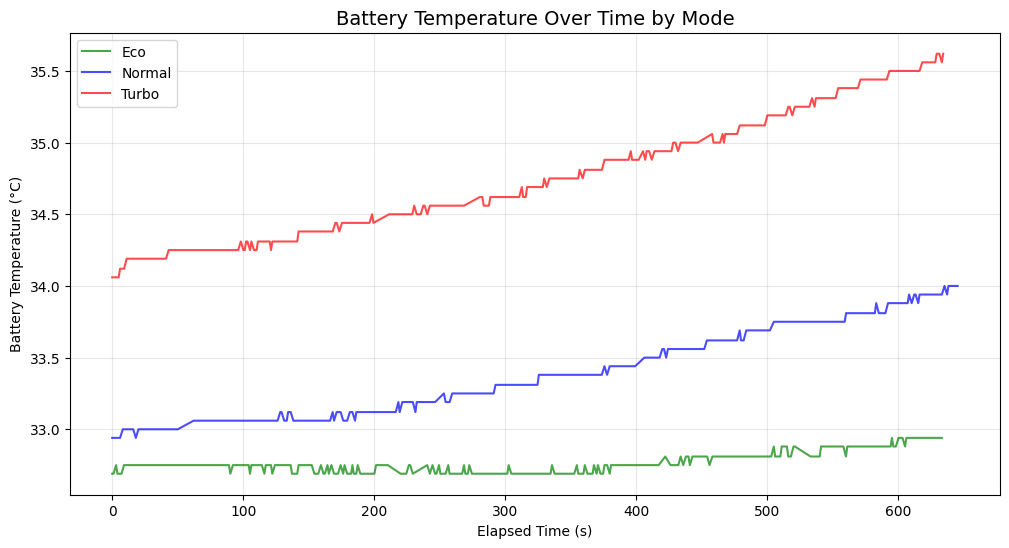

-> Figure saved: battery_eda_boxplot_temp_escalar.png


/var/folders/60/n8m7rtz14nq1qy7tkbtk9zqc0000gn/T/ipykernel_50223/643805886.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='mode', y='temp_battery', data=df, palette='viridis')


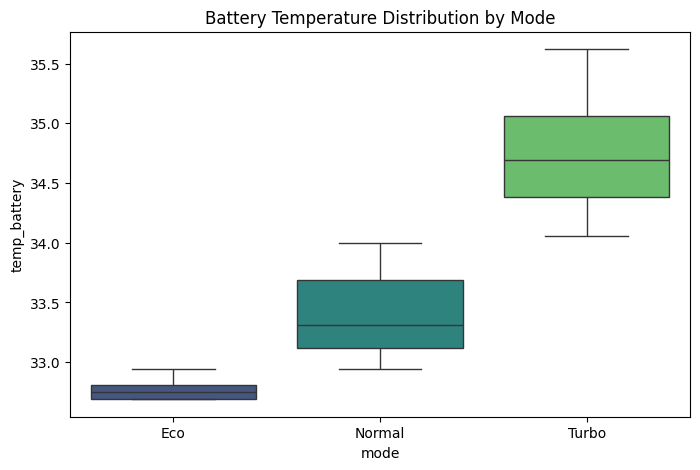

-> Figure saved: battery_eda_correlacao_escalar.png


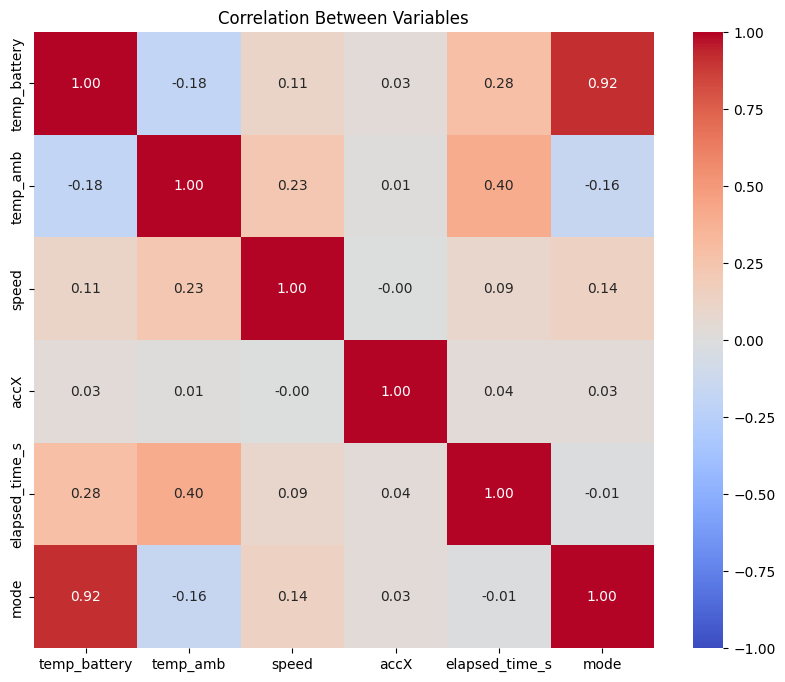

-> Figure saved: battery_eda_distribuicao_escalar.png


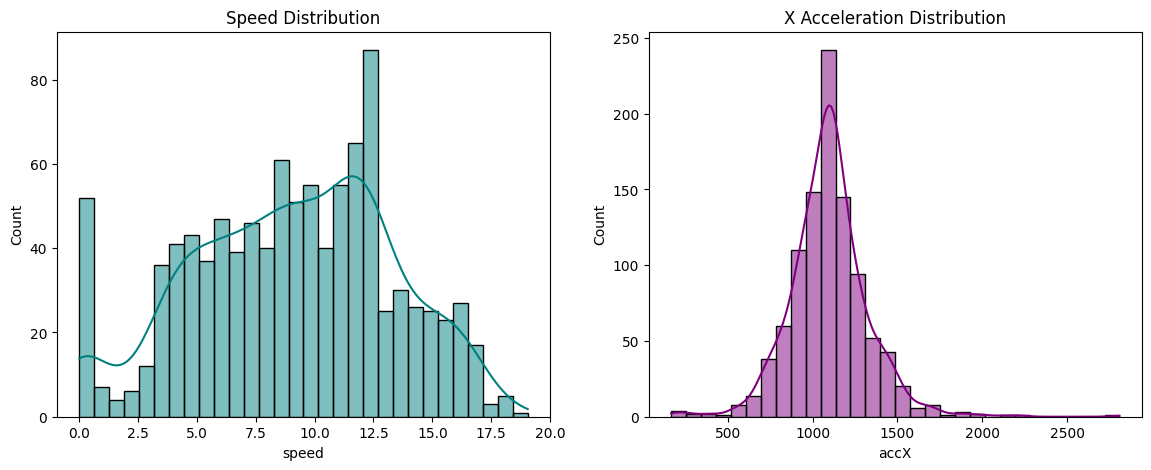

In [45]:
print("\n[Descriptive Statistics]")
print(df[['temp_battery', 'speed', 'accX', 'temp_amb']].describe().T)

print("\n[Zero Checks (Possible Sensor Failures)]")
zeros_speed = (df['speed'] == 0).sum()
zeros_gps = ((df['lat'] == 0) & (df['lon'] == 0)).sum()
print(f"Records with Speed = 0: {zeros_speed} ({zeros_speed/len(df):.1%})")
print(f"Records with GPS = 0 (Lat/Lon=0): {zeros_gps} ({zeros_gps/len(df):.1%})")

# Plot: Battery Temperature Over Time by Mode
plt.figure(figsize=(12, 6))
modes = {0: 'Eco', 1: 'Normal', 2: 'Turbo'}
colors = {0: 'green', 1: 'blue', 2: 'red'}

for m_code, m_name in modes.items():
    subset = df[df['mode'] == m_code]
    plt.plot(subset['elapsed_time_s'], subset['temp_battery'], label=m_name, color=colors[m_code], alpha=0.7)

plt.title('Battery Temperature Over Time by Mode', fontsize=14)
plt.xlabel('Elapsed Time (s)')
plt.ylabel('Battery Temperature (°C)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('../images/battery_eda_evolucao_temp_escalar.png')
print("-> Figure saved: battery_eda_evolucao_temp_escalar.png")
plt.show()
plt.close()

# Plot: Comparative Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x='mode', y='temp_battery', data=df, palette='viridis')
plt.xticks([0, 1, 2], ['Eco', 'Normal', 'Turbo'])
plt.title('Battery Temperature Distribution by Mode')
plt.savefig('../images/battery_eda_boxplot_temp_escalar.png')
print("-> Figure saved: battery_eda_boxplot_temp_escalar.png")
plt.show()
plt.close()

# Plot: Correlation Matrix
plt.figure(figsize=(10, 8))
cols_corr = ['temp_battery', 'temp_amb', 'speed', 'accX', 'elapsed_time_s', 'mode']
corr = df[cols_corr].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Between Variables')
plt.savefig('../images/battery_eda_correlacao_escalar.png')
print("-> Figure saved: battery_eda_correlacao_escalar.png")
plt.show()
plt.close()

# Speed and Acceleration Histograms
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['speed'], bins=30, kde=True, ax=ax[0], color='teal')
ax[0].set_title('Speed Distribution')
sns.histplot(df['accX'], bins=30, kde=True, ax=ax[1], color='purple')
ax[1].set_title('X Acceleration Distribution')
plt.savefig('../images/battery_eda_distribuicao_escalar.png')
print("-> Figure saved: battery_eda_distribuicao_escalar.png")
plt.show()
plt.close()

## Treinamento e Predição - Valores escalares

In [46]:
features = ['mode', 'temp_amb', 'speed', 'accX', 'accY', 'accZ', 'elapsed_time_s']
target = 'temp_battery'

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

results = []

def run_model(model, name, param_dist):
    print(f"Treinando {name}...")
    random_search = RandomizedSearchCV(model, param_dist, n_iter=10, cv=3, 
                                     scoring='neg_mean_squared_error', 
                                     random_state=42, n_jobs=-1)
    
    start_total = time.time()
    
    # Monitoramento Treino
    with MonitorHardware(f"Treino_{name}") as mon_t:
        random_search.fit(X_train_scaled, y_train)
    
    time_train = time.time() - start_total
    best_model = random_search.best_estimator_
    
    # Monitoramento Predição
    start_pred = time.time()
    with MonitorHardware(f"Pred_{name}") as mon_p:
        y_pred = best_model.predict(X_test_scaled)
    time_pred = time.time() - start_pred
    
    # Métricas
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    results.append({
        "Modelo": name,
        "R²": r2, "MAE": mae, "RMSE": rmse,
        "Tempo Treino": time_train,
        "CPU (%)": mon_t.dados['cpu_avg'],
        "RAM (MB)": mon_t.dados['ram_max'],
        "Melhor Config": str(random_search.best_params_)
    })
    print(f""""Modelo": {name},
        "R²": {r2}, "MAE": {mae}, "RMSE": {rmse},
        "Tempo Treino": {time_train},
        "CPU (%)": {mon_t.dados['cpu_avg']},
        "RAM (MB)": {mon_t.dados['ram_max']},
        "Melhor Config": {str(random_search.best_params_)}""")

Treinando KNN...
[Treino_KNN] CPU Méd: 6.5% (Max: 10.5%) | RAM Méd: 827.2MB (Max: 942.0MB)
[Pred_KNN] CPU Méd: 10.0% (Max: 10.0%) | RAM Méd: 940.9MB (Max: 940.9MB)
"Modelo": KNN,
        "R²": 0.9792686884589853, "MAE": 0.07088231940409796, "RMSE": 0.12411997935302833,
        "Tempo Treino": 0.21932172775268555,
        "CPU (%)": 6.529999999999999,
        "RAM (MB)": 941.984375,
        "Melhor Config": {'weights': 'distance', 'n_neighbors': np.int64(3), 'metric': 'manhattan'}
Treinando DecisionTree...
[Treino_DecisionTree] CPU Méd: 9.9% (Max: 9.9%) | RAM Méd: 940.9MB (Max: 940.9MB)
[Pred_DecisionTree] CPU Méd: 10.0% (Max: 10.0%) | RAM Méd: 979.3MB (Max: 979.3MB)
"Modelo": DecisionTree,
        "R²": 0.9992722013319254, "MAE": 0.01114356435643623, "RMSE": 0.02325594190488528,
        "Tempo Treino": 0.106842041015625,
        "CPU (%)": 9.89,
        "RAM (MB)": 940.9375,
        "Melhor Config": {'min_samples_split': np.int64(2), 'min_samples_leaf': np.int64(3), 'max_depth': None, 

/Users/hitalo/Documents/tcc-datalogger/datalogger-data/venv312/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/hitalo/Documents/tcc-datalogger/datalogger-data/venv312/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/hitalo/Documents/tcc-datalogger/datalogger-data/venv312/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/hitalo/Documents/tcc-datalogger/datalogger-data/venv312/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: Converge

[Treino_MLP] CPU Méd: 2.0% (Max: 10.0%) | RAM Méd: 1128.5MB (Max: 1131.0MB)
[Pred_MLP] CPU Méd: 10.0% (Max: 10.0%) | RAM Méd: 1131.0MB (Max: 1131.0MB)
"Modelo": MLP,
        "R²": 0.8481772071160927, "MAE": 0.2595092676979256, "RMSE": 0.33588978299226013,
        "Tempo Treino": 1.212934970855713,
        "CPU (%)": 2.0218181818181815,
        "RAM (MB)": 1130.984375,
        "Melhor Config": {'solver': 'adam', 'learning_rate_init': 0.01, 'hidden_layer_sizes': (100,), 'alpha': 0.01, 'activation': 'tanh'}

=== FINAL RESULTS TABLE ===
          Modelo       R²      MAE     RMSE  Tempo Treino   CPU (%)    RAM (MB)
    RandomForest 0.999409 0.012271 0.020961      0.676952  2.893333 1026.171875
    DecisionTree 0.999272 0.011144 0.023256      0.106842  9.890000  940.937500
GradientBoosting 0.998555 0.024342 0.032764      0.655516 10.306667 1115.453125
             KNN 0.979269 0.070882 0.124120      0.219322  6.530000  941.984375
             MLP 0.848177 0.259509 0.335890      1.212935  2.

/var/folders/60/n8m7rtz14nq1qy7tkbtk9zqc0000gn/T/ipykernel_50223/3790969351.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='R²', y='Modelo', data=results_df, palette='viridis')


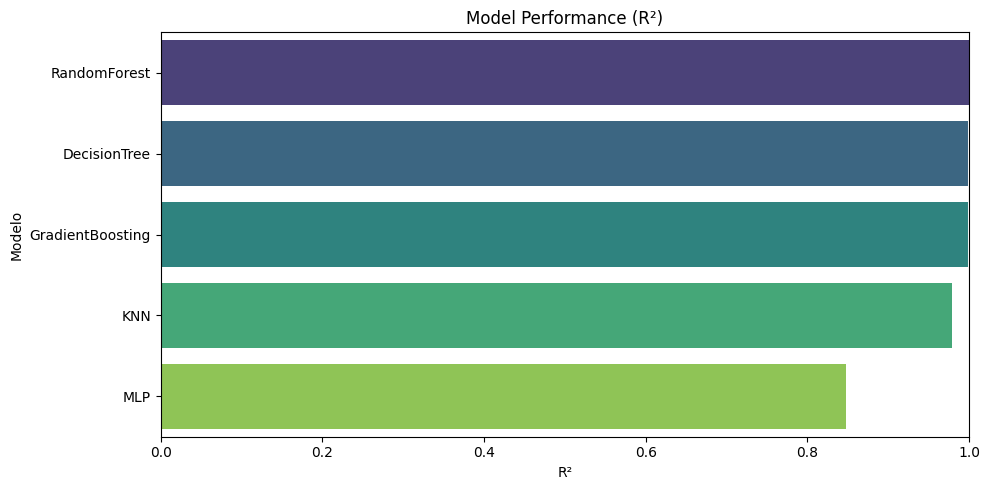

Results saved to 'battery_resultados_finais_train_escalar.csv' and 'battery_performance_modelos_escalar.png'


In [47]:
run_model(KNeighborsRegressor(), "KNN", {
    'n_neighbors': np.arange(3, 21, 2),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
})

run_model(DecisionTreeRegressor(random_state=42), "DecisionTree", {
    'max_depth': [None] + list(np.arange(5, 30, 5)),
    'min_samples_split': np.arange(2, 11, 2),
    'min_samples_leaf': np.arange(1, 11, 2),
    'criterion': ['squared_error', 'absolute_error']
})

run_model(RandomForestRegressor(random_state=42), "RandomForest", {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 1.0]
})

run_model(XGBRegressor(random_state=42), "GradientBoosting", {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
})

run_model(MLPRegressor(random_state=42, max_iter=1000), "MLP", {
    'hidden_layer_sizes': [(50,), (100,), (50, 25), (64, 32)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.01]
})

# Final Results
results_df = pd.DataFrame(results).sort_values(by="R²", ascending=False)
print("\n=== FINAL RESULTS TABLE ===")
print(results_df[['Modelo', 'R²', 'MAE', 'RMSE', 'Tempo Treino', 'CPU (%)', 'RAM (MB)']].to_string(index=False))

# Save
results_df.to_csv('battery_resultados_finais_train_escalar.csv', index=False)
plt.figure(figsize=(10, 5))
sns.barplot(x='R²', y='Modelo', data=results_df, palette='viridis')
plt.title('Model Performance (R²)')
plt.xlim(0, 1)
plt.tight_layout()
plt.savefig('../images/battery_performance_modelos_escalar.png')
plt.show()
print("Results saved to 'battery_resultados_finais_train_escalar.csv' and 'battery_performance_modelos_escalar.png'")

## Treinamento e Predição - Médias Móveis

In [48]:
# ==============================================================================
# NOVA ETAPA: Engenharia de Features (Criando Memória para o Modelo)
# ==============================================================================
print("--- Gerando Features de Inércia Térmica ---")

# Garantir que está ordenado por tempo para os cálculos funcionarem
df = df.sort_values(by=['mode', 'elapsed_time_s'])

# 1. Médias Móveis
# Janelas de 30s e 60s para Velocidade e Aceleração (Magnitude)
df['acc_mag'] = np.sqrt(df['accX']**2 + df['accY']**2 + df['accZ']**2) # Magnitude da aceleração

for window in [30, 60, 120]: # Janelas de 30s, 1min e 2min
    # Média da velocidade nos últimos X segundos
    df[f'speed_roll_mean_{window}'] = df.groupby('mode')['speed'].transform(
        lambda x: x.rolling(window=window, min_periods=1).mean()
    )
    # Média da aceleração nos últimos X segundos (esforço)
    df[f'acc_roll_mean_{window}'] = df.groupby('mode')['acc_mag'].transform(
        lambda x: x.rolling(window=window, min_periods=1).mean()
    )

# 2. Energia Acumulada (Integral aproximada)
# Soma cumulativa de Velocidade (distância teórica) e Aceleração (esforço total)
df['speed_cumsum'] = df.groupby('mode')['speed'].cumsum()
df['acc_cumsum'] = df.groupby('mode')['acc_mag'].cumsum()

# 3. Diferença de Temperatura Ambiente
# O quão mais quente que o ambiente a bateria já está? (Se tiver essa info no início)
# Como não temos temp anterior, vamos usar o tempo decorrido como fator de "fator de aquecimento"
df['heating_factor'] = df['elapsed_time_s'] * df['speed_roll_mean_60'] 

# Atualizar lista de features para o treinamento
features = [
    'mode', 'temp_amb', 'elapsed_time_s',
    'speed_roll_mean_30', 'speed_roll_mean_60', 'speed_roll_mean_120',
    'acc_roll_mean_30', 'acc_roll_mean_60',
    'speed_cumsum', 'acc_cumsum', 'heating_factor'
]
# Note que removemos 'speed', 'accX', etc. instantâneos, pois eles são ruído.
# Mantivemos 'elapsed_time_s' pois o tempo total é crucial para aquecimento.

target = 'temp_battery'

print(f"Novas Features geradas: {features}")
df = df.dropna() # Remove linhas iniciais que podem ter ficado vazias no rolling

--- Gerando Features de Inércia Térmica ---
Novas Features geradas: ['mode', 'temp_amb', 'elapsed_time_s', 'speed_roll_mean_30', 'speed_roll_mean_60', 'speed_roll_mean_120', 'acc_roll_mean_30', 'acc_roll_mean_60', 'speed_cumsum', 'acc_cumsum', 'heating_factor']


Treinando KNN...
[Treino_KNN] CPU Méd: 9.3% (Max: 9.3%) | RAM Méd: 1132.0MB (Max: 1132.0MB)
[Pred_KNN] CPU Méd: 10.0% (Max: 10.0%) | RAM Méd: 1133.1MB (Max: 1133.1MB)
"Modelo": KNN,
        "R²": 0.9993320602359143, "MAE": 0.012517919604637478, "RMSE": 0.022279064717368874,
        "Tempo Treino": 0.10857391357421875,
        "CPU (%)": 9.27,
        "RAM (MB)": 1132.015625,
        "Melhor Config": {'weights': 'distance', 'n_neighbors': np.int64(3), 'metric': 'manhattan'}
Treinando DecisionTree...
[Treino_DecisionTree] CPU Méd: 10.0% (Max: 10.0%) | RAM Méd: 1133.1MB (Max: 1133.1MB)
[Pred_DecisionTree] CPU Méd: 10.0% (Max: 10.0%) | RAM Méd: 1133.6MB (Max: 1133.6MB)
"Modelo": DecisionTree,
        "R²": 0.9992420478766997, "MAE": 0.011515676567657604, "RMSE": 0.02373281165116348,
        "Tempo Treino": 0.11273598670959473,
        "CPU (%)": 10.03,
        "RAM (MB)": 1133.0625,
        "Melhor Config": {'min_samples_split': np.int64(10), 'min_samples_leaf': np.int64(3), 'max_depth': N

/Users/hitalo/Documents/tcc-datalogger/datalogger-data/venv312/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/hitalo/Documents/tcc-datalogger/datalogger-data/venv312/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/hitalo/Documents/tcc-datalogger/datalogger-data/venv312/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/hitalo/Documents/tcc-datalogger/datalogger-data/venv312/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: Converge

[Treino_MLP] CPU Méd: 1.8% (Max: 10.1%) | RAM Méd: 1214.4MB (Max: 1215.2MB)
[Pred_MLP] CPU Méd: 10.0% (Max: 10.0%) | RAM Méd: 1215.2MB (Max: 1215.2MB)
"Modelo": MLP,
        "R²": 0.9879174807790441, "MAE": 0.06715793239076387, "RMSE": 0.09475607281039436,
        "Tempo Treino": 1.7856481075286865,
        "CPU (%)": 1.81375,
        "RAM (MB)": 1215.15625,
        "Melhor Config": {'solver': 'adam', 'learning_rate_init': 0.01, 'hidden_layer_sizes': (50, 25), 'alpha': 0.001, 'activation': 'tanh'}

=== FINAL RESULTS TABLE ===
          Modelo       R²      MAE     RMSE  Tempo Treino   CPU (%)    RAM (MB)
    RandomForest 0.999428 0.012281 0.020615      0.769614  3.475714 1150.453125
             KNN 0.999332 0.012518 0.022279      0.108574  9.270000 1132.015625
    DecisionTree 0.999242 0.011516 0.023733      0.112736 10.030000 1133.062500
GradientBoosting 0.998729 0.017904 0.030728      0.758459 11.548571 1213.125000
             MLP 0.987917 0.067158 0.094756      1.785648  1.813750 

/var/folders/60/n8m7rtz14nq1qy7tkbtk9zqc0000gn/T/ipykernel_50223/3591509730.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='R²', y='Modelo', data=results_df, palette='viridis')


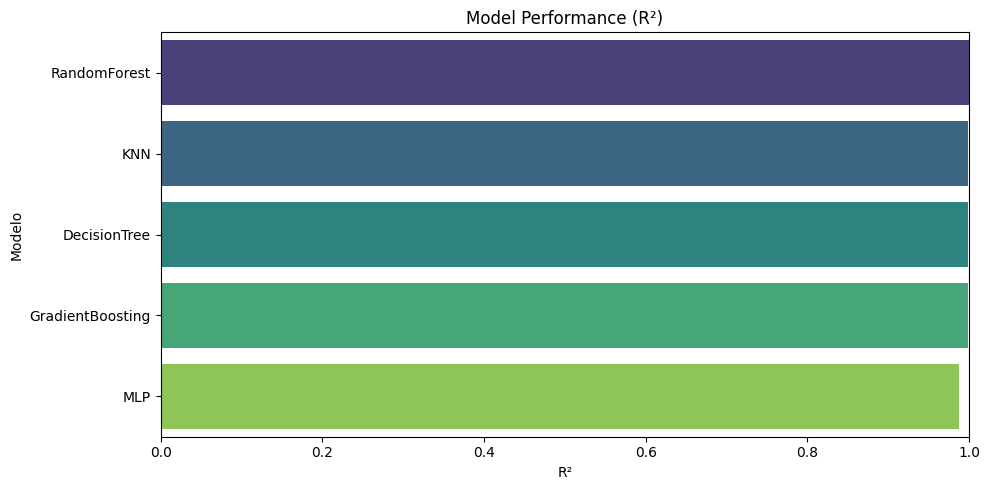

Results saved to 'battery_resultados_finais_train_media.csv' and 'battery_performance_modelos_media.png'


In [49]:
X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

results = []

run_model(KNeighborsRegressor(), "KNN", {
    'n_neighbors': np.arange(3, 21, 2),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
})

run_model(DecisionTreeRegressor(random_state=42), "DecisionTree", {
    'max_depth': [None] + list(np.arange(5, 30, 5)),
    'min_samples_split': np.arange(2, 11, 2),
    'min_samples_leaf': np.arange(1, 11, 2),
    'criterion': ['squared_error', 'absolute_error']
})

run_model(RandomForestRegressor(random_state=42), "RandomForest", {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 1.0]
})

run_model(XGBRegressor(random_state=42), "GradientBoosting", {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
})

run_model(MLPRegressor(random_state=42, max_iter=1000), "MLP", {
    'hidden_layer_sizes': [(50,), (100,), (50, 25), (64, 32)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.01]
})

# Final Results
results_df = pd.DataFrame(results).sort_values(by="R²", ascending=False)
print("\n=== FINAL RESULTS TABLE ===")
print(results_df[['Modelo', 'R²', 'MAE', 'RMSE', 'Tempo Treino', 'CPU (%)', 'RAM (MB)']].to_string(index=False))

# Save
results_df.to_csv('battery_resultados_finais_train_media.csv', index=False)
plt.figure(figsize=(10, 5))
sns.barplot(x='R²', y='Modelo', data=results_df, palette='viridis')
plt.title('Model Performance (R²)')
plt.xlim(0, 1)
plt.tight_layout()
plt.savefig('../images/battery_performance_modelos_media.png')
plt.show()
print("Results saved to 'battery_resultados_finais_train_media.csv' and 'battery_performance_modelos_media.png'")

# Usando dados tratados (Sem outliers)

## Reprocessando os dados

In [50]:
files = [
    "../data/processed/teste_eco_10_01_4.csv",
    "../data/processed/teste_nor_10_01.csv",
    "../data/processed/teste_tur_10_01.csv"
]

df_list = []
for file_path in files:
    try:
        temp_df = pd.read_csv(file_path)
        df_list.append(temp_df)
        print(f"Carregado: {file_path}")
    except FileNotFoundError:
        print(f"ERRO: Arquivo {file_path} não encontrado.")

if not df_list:
    raise ValueError("Nenhum arquivo foi carregado. Verifique os caminhos.")

df = pd.concat(df_list, ignore_index=True)

# Mapear os modos para valores numéricos
def map_mode(val):
    val = str(val).lower()
    if 'eco' in val: return 0
    if 'nor' in val: return 1
    if 'tur' in val: return 2
    return -1 # Caso de erro

df['mode'] = df['testCase'].apply(map_mode)

# Calcular o tempo decorrido em segundos desde o início de teste em cada modo
df = df.sort_values(by=['testCase', 'receivedAtMs'])
df['elapsed_time_s'] = df.groupby('testCase')['receivedAtMs'].transform(lambda x: (x - x.min()) / 1000.0)

#Deixando só as colunas relevantes
cols_to_drop = ['id', 'deviceId', 'sampleId', 'motorC', 'testCase', 
                'receivedAt', 'receivedAtMs', 'headingDeg', 'accuracyM']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns], errors='ignore')

#Removendo outliers de temperatura da bateria (falha na coleta)
df = df.dropna(subset=['batteryC'])
df = df[ (df['batteryC'] > 0) & (df['batteryC'] < 150) ]

#Removendo outliers de temperatura da bateria (falha na coleta)
df = df.dropna(subset=['referenceC'])
df = df[ (df['referenceC'] > 0) & (df['referenceC'] < 150) ]

df = df.rename(columns={
    'referenceC': 'temp_amb',
    'speedMps': 'speed',
    'lng': 'lon',
    'accel_x': 'accX', 
    'accel_y': 'accY', 
    'accel_z': 'accZ',
    'batteryC': 'temp_battery'
})

print(f"Dataset processado: {df.shape[0]} registros.")
df.head()

Carregado: ../data/processed/teste_eco_10_01_4.csv
Carregado: ../data/processed/teste_nor_10_01.csv
Carregado: ../data/processed/teste_tur_10_01.csv
Dataset processado: 1006 registros.


,lat,lon,speed,temp_battery,temp_amb,accX,accY,accZ,mode,elapsed_time_s
0,-8.055623,-34.951128,0.000000,32.69,30.44,1084,332,165,0,0.000
1,-8.055622,-34.951125,0.000000,32.69,30.44,1094,333,130,0,1.022
2,-8.055609,-34.951112,0.740566,32.75,30.50,1093,334,134,0,2.998
3,-8.055603,-34.951105,0.394090,32.69,30.50,1094,333,137,0,4.022
4,-8.055606,-34.951103,0.561951,32.69,30.56,1093,332,132,0,7.139


## Análise exploratória


[Descriptive Statistics]
               count         mean         std     min         25%  \
temp_battery  1006.0    33.663082    0.886562   32.69   32.810000   
speed         1006.0     9.031026    4.271617    0.00    5.885671   
accX          1006.0  1096.579523  233.007021  167.00  970.000000   
temp_amb      1006.0    31.884920    0.489337   30.44   31.560000   

                      50%          75%          max  
temp_battery    33.380000    34.380000    35.620000  
speed            9.318798    12.169095    19.051404  
accX          1097.000000  1206.750000  2808.000000  
temp_amb        31.880000    32.250000    33.120000  

[Zero Checks (Possible Sensor Failures)]
Records with Speed = 0: 30 (3.0%)
Records with GPS = 0 (Lat/Lon=0): 0 (0.0%)
-> Figure saved: battery_eda_evolucao_temp_tratados.png


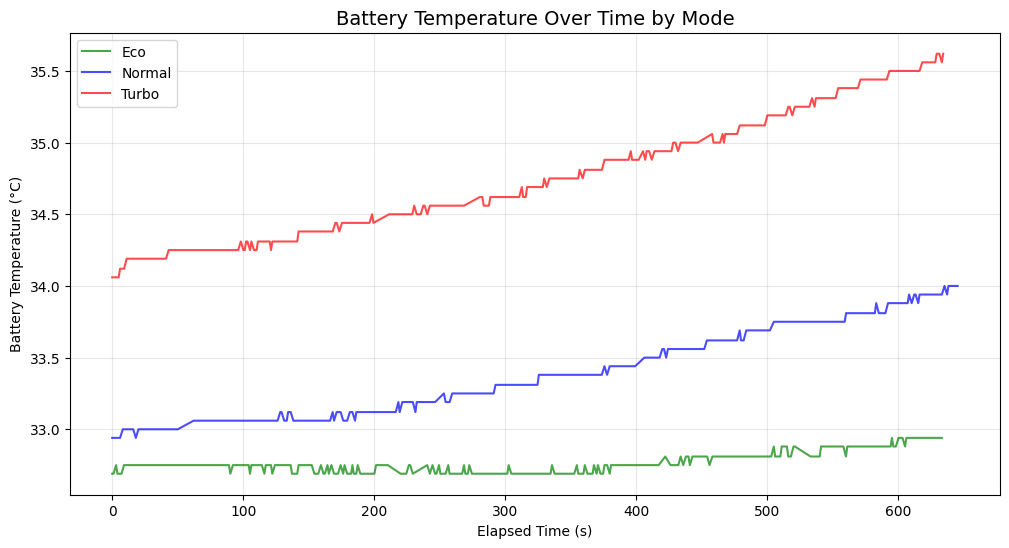

/var/folders/60/n8m7rtz14nq1qy7tkbtk9zqc0000gn/T/ipykernel_50223/4083448866.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='mode', y='temp_battery', data=df, palette='viridis')


-> Figure saved: battery_eda_boxplot_temp_tratados.png


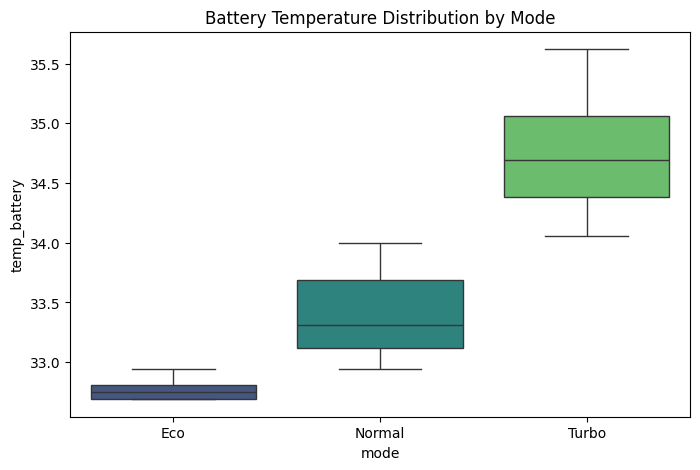

-> Figure saved: battery_eda_correlacao_tratados.png


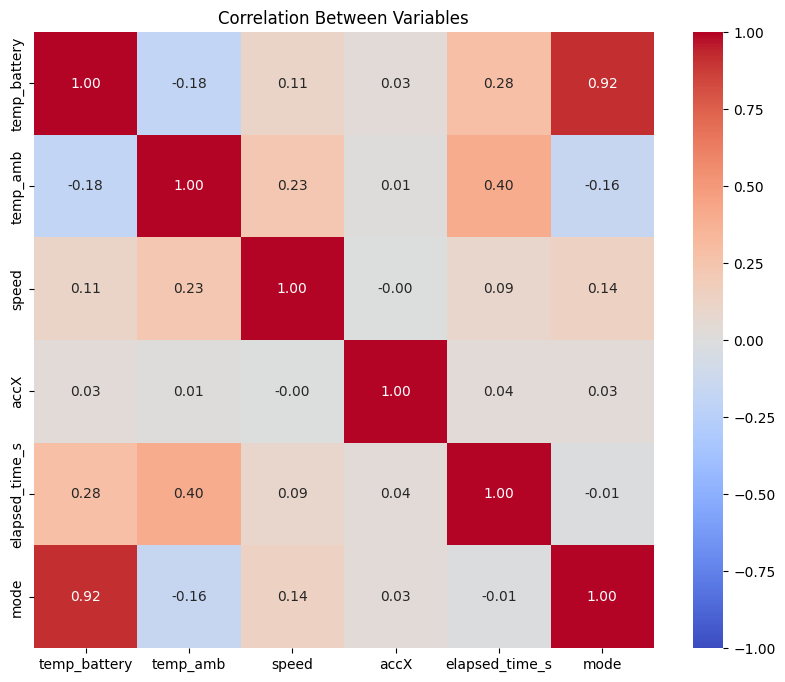

-> Figure saved: battery_eda_distribuicao_tratados.png


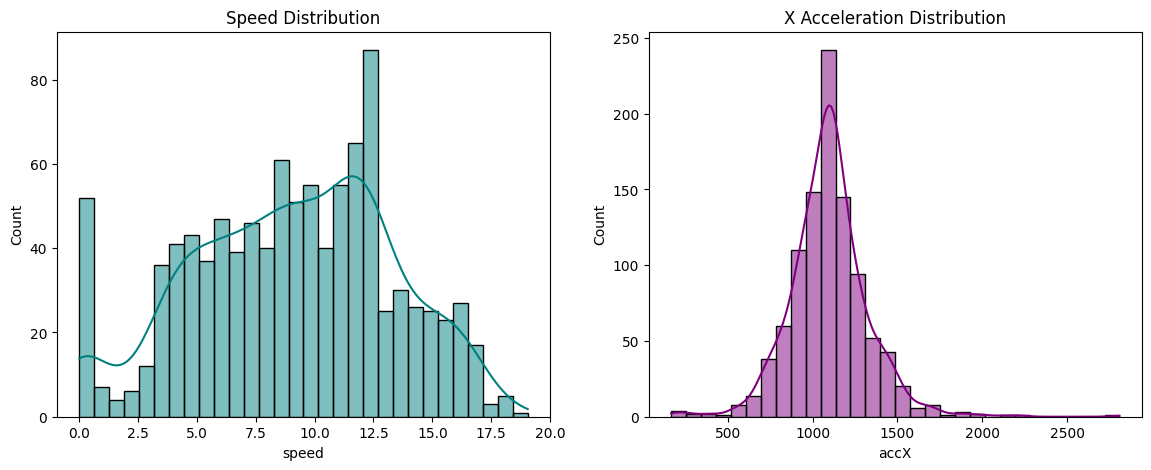

In [51]:
print("\n[Descriptive Statistics]")
print(df[['temp_battery', 'speed', 'accX', 'temp_amb']].describe().T)

print("\n[Zero Checks (Possible Sensor Failures)]")
zeros_speed = (df['speed'] == 0).sum()
zeros_gps = ((df['lat'] == 0) & (df['lon'] == 0)).sum()
print(f"Records with Speed = 0: {zeros_speed} ({zeros_speed/len(df):.1%})")
print(f"Records with GPS = 0 (Lat/Lon=0): {zeros_gps} ({zeros_gps/len(df):.1%})")

# Plot: Battery Temperature Over Time by Mode
plt.figure(figsize=(12, 6))
modes = {0: 'Eco', 1: 'Normal', 2: 'Turbo'}
colors = {0: 'green', 1: 'blue', 2: 'red'}

for m_code, m_name in modes.items():
    subset = df[df['mode'] == m_code]
    plt.plot(subset['elapsed_time_s'], subset['temp_battery'], label=m_name, color=colors[m_code], alpha=0.7)

plt.title('Battery Temperature Over Time by Mode', fontsize=14)
plt.xlabel('Elapsed Time (s)')
plt.ylabel('Battery Temperature (°C)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('../images/battery_eda_evolucao_temp_tratados.png')
print("-> Figure saved: battery_eda_evolucao_temp_tratados.png")
plt.show()
plt.close()

# Plot: Comparative Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x='mode', y='temp_battery', data=df, palette='viridis')
plt.xticks([0, 1, 2], ['Eco', 'Normal', 'Turbo'])
plt.title('Battery Temperature Distribution by Mode')
plt.savefig('../images/battery_eda_boxplot_temp_tratados.png')
print("-> Figure saved: battery_eda_boxplot_temp_tratados.png")
plt.show()
plt.close()

# Plot: Correlation Matrix
plt.figure(figsize=(10, 8))
cols_corr = ['temp_battery', 'temp_amb', 'speed', 'accX', 'elapsed_time_s', 'mode']
corr = df[cols_corr].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Between Variables')
plt.savefig('../images/battery_eda_correlacao_tratados.png')
print("-> Figure saved: battery_eda_correlacao_tratados.png")
plt.show()
plt.close()

# Speed and Acceleration Histograms
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['speed'], bins=30, kde=True, ax=ax[0], color='teal')
ax[0].set_title('Speed Distribution')
sns.histplot(df['accX'], bins=30, kde=True, ax=ax[1], color='purple')
ax[1].set_title('X Acceleration Distribution')
plt.savefig('../images/battery_eda_distribuicao_tratados.png')
print("-> Figure saved: battery_eda_distribuicao_tratados.png")
plt.show()
plt.close()

## Treinamento e Predição

Treinando KNN...
[Treino_KNN] CPU Méd: 8.2% (Max: 8.2%) | RAM Méd: 1340.9MB (Max: 1340.9MB)
[Pred_KNN] CPU Méd: 10.0% (Max: 10.0%) | RAM Méd: 1342.5MB (Max: 1342.5MB)
"Modelo": KNN,
        "R²": 0.9792686884589853, "MAE": 0.07088231940409796, "RMSE": 0.12411997935302833,
        "Tempo Treino": 0.1114339828491211,
        "CPU (%)": 8.17,
        "RAM (MB)": 1340.875,
        "Melhor Config": {'weights': 'distance', 'n_neighbors': np.int64(3), 'metric': 'manhattan'}
Treinando DecisionTree...
[Treino_DecisionTree] CPU Méd: 10.0% (Max: 10.0%) | RAM Méd: 1342.5MB (Max: 1342.5MB)
[Pred_DecisionTree] CPU Méd: 10.0% (Max: 10.0%) | RAM Méd: 1342.6MB (Max: 1342.6MB)
"Modelo": DecisionTree,
        "R²": 0.9992722013319254, "MAE": 0.01114356435643623, "RMSE": 0.02325594190488528,
        "Tempo Treino": 0.1061408519744873,
        "CPU (%)": 10.0,
        "RAM (MB)": 1342.546875,
        "Melhor Config": {'min_samples_split': np.int64(2), 'min_samples_leaf': np.int64(3), 'max_depth': None, 'cr

/Users/hitalo/Documents/tcc-datalogger/datalogger-data/venv312/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/hitalo/Documents/tcc-datalogger/datalogger-data/venv312/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/hitalo/Documents/tcc-datalogger/datalogger-data/venv312/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/hitalo/Documents/tcc-datalogger/datalogger-data/venv312/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: Converge

[Treino_MLP] CPU Méd: 2.2% (Max: 10.1%) | RAM Méd: 1376.6MB (Max: 1376.9MB)
[Pred_MLP] CPU Méd: 10.0% (Max: 10.0%) | RAM Méd: 1374.5MB (Max: 1374.5MB)
"Modelo": MLP,
        "R²": 0.8481772071160927, "MAE": 0.2595092676979256, "RMSE": 0.33588978299226013,
        "Tempo Treino": 1.319751262664795,
        "CPU (%)": 2.225,
        "RAM (MB)": 1376.859375,
        "Melhor Config": {'solver': 'adam', 'learning_rate_init': 0.01, 'hidden_layer_sizes': (100,), 'alpha': 0.01, 'activation': 'tanh'}

=== FINAL RESULTS TABLE ===
          Modelo       R²      MAE     RMSE  Tempo Treino   CPU (%)    RAM (MB)
    RandomForest 0.999409 0.012271 0.020961      0.665713  3.346667 1355.218750
    DecisionTree 0.999272 0.011144 0.023256      0.106141 10.000000 1342.546875
GradientBoosting 0.998555 0.024342 0.032764      0.654916 11.783333 1375.718750
             KNN 0.979269 0.070882 0.124120      0.111434  8.170000 1340.875000
             MLP 0.848177 0.259509 0.335890      1.319751  2.225000 1376.8

/var/folders/60/n8m7rtz14nq1qy7tkbtk9zqc0000gn/T/ipykernel_50223/1535077188.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='R²', y='Modelo', data=results_df, palette='viridis')


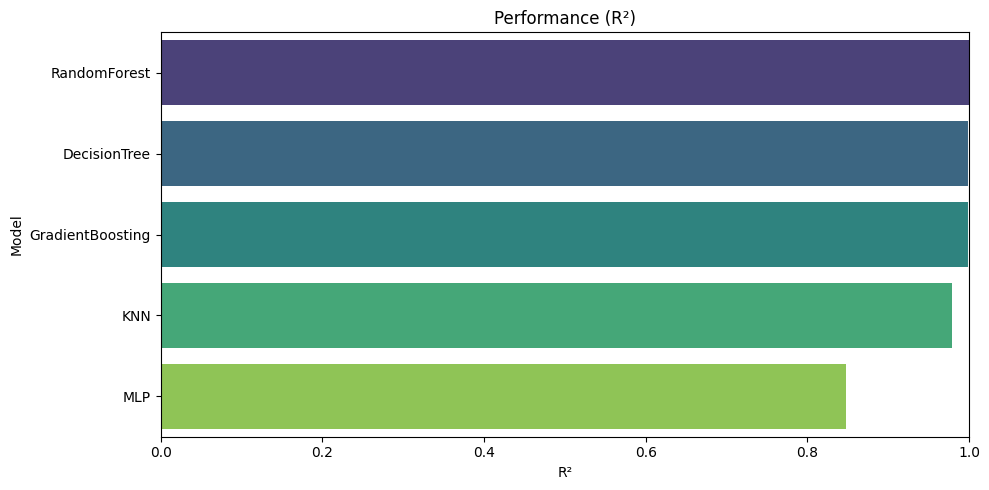

Results saved to 'battery_resultados_finais_train_tratados.csv' and 'battery_performance_modelos_tratados.png'


In [52]:
features = ['mode', 'temp_amb', 'speed', 'accX', 'accY', 'accZ', 'elapsed_time_s']
target = 'temp_battery'

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

results = []

run_model(KNeighborsRegressor(), "KNN", {
    'n_neighbors': np.arange(3, 21, 2),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
})

run_model(DecisionTreeRegressor(random_state=42), "DecisionTree", {
    'max_depth': [None] + list(np.arange(5, 30, 5)),
    'min_samples_split': np.arange(2, 11, 2),
    'min_samples_leaf': np.arange(1, 11, 2),
    'criterion': ['squared_error', 'absolute_error']
})

run_model(RandomForestRegressor(random_state=42), "RandomForest", {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 1.0]
})

run_model(XGBRegressor(random_state=42), "GradientBoosting", {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
})

run_model(MLPRegressor(random_state=42, max_iter=1000), "MLP", {
    'hidden_layer_sizes': [(50,), (100,), (50, 25), (64, 32)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.01]
})

# Final Results
results_df = pd.DataFrame(results).sort_values(by="R²", ascending=False)
print("\n=== FINAL RESULTS TABLE ===")
print(results_df[['Modelo', 'R²', 'MAE', 'RMSE', 'Tempo Treino', 'CPU (%)', 'RAM (MB)']].to_string(index=False))

# Save
results_df.to_csv('battery_resultados_finais_train_tratados.csv', index=False)
plt.figure(figsize=(10, 5))
ax = sns.barplot(x='R²', y='Modelo', data=results_df, palette='viridis')
plt.title('Performance (R²)')
ax.set_ylabel('Model')
plt.xlim(0, 1)
plt.tight_layout()
plt.savefig('../images/battery_performance_modelos_tratados.png')
plt.show()
print("Results saved to 'battery_resultados_finais_train_tratados.csv' and 'battery_performance_modelos_tratados.png'")